## EDA

### Setup

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import Counter

from src.utils.seed import set_seed
from src.data_operations.dataset import NEUDefectDataset
from src.data_operations.transforms import get_val_transforms

set_seed(42)
splits_root = project_root / "data" / "splits"

Seed set to 42


### Load All Three Splits

In [2]:
train_ds = NEUDefectDataset(splits_root, split="train", transform=get_val_transforms())
val_ds   = NEUDefectDataset(splits_root, split="val",   transform=get_val_transforms())
test_ds  = NEUDefectDataset(splits_root, split="test",  transform=get_val_transforms())

print(train_ds)
print(val_ds)
print(test_ds)
print(f"\nClass mapping: {train_ds.class_to_idx}")


Class mapping: {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}


### Split Size and Proportions

In [3]:
total = len(train_ds) + len(val_ds) + len(test_ds)

print(f"{'Split':<10} {'Images':>8} {'Proportion':>12}")
print("-" * 32)
print(f"{'Train':<10} {len(train_ds):>8} {len(train_ds)/total:>12.1%}")
print(f"{'Val':<10} {len(val_ds):>8} {len(val_ds)/total:>12.1%}")
print(f"{'Test':<10} {len(test_ds):>8} {len(test_ds)/total:>12.1%}")
print(f"{'Total':<10} {total:>8}")

Split        Images   Proportion
--------------------------------
Train          1254        69.7%
Val             270        15.0%
Test            276        15.3%
Total          1800


### Class Distribution Per Split

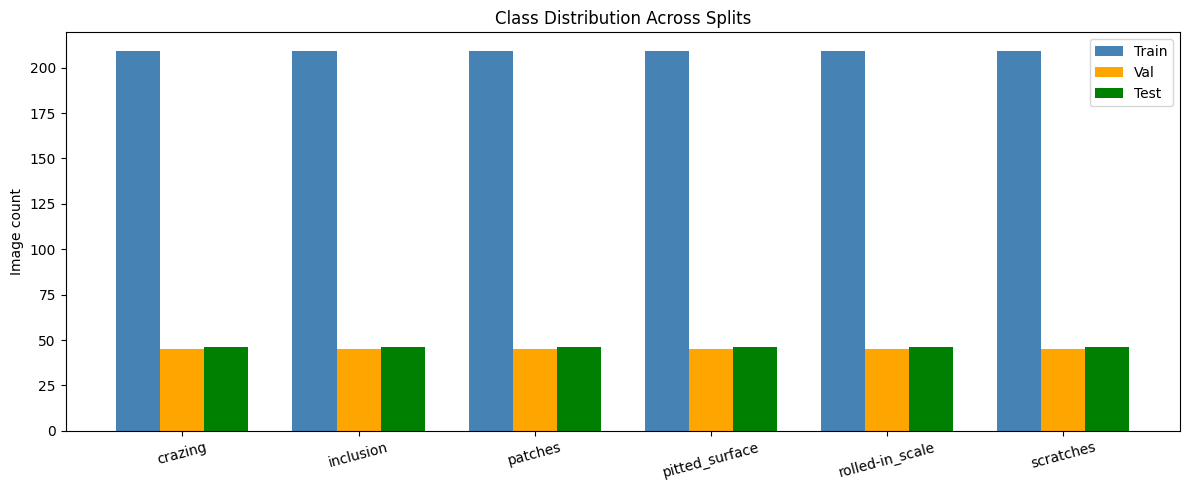


Class                   Train      Val     Test
------------------------------------------------
crazing                   209       45       46
inclusion                 209       45       46
patches                   209       45       46
pitted_surface            209       45       46
rolled-in_scale           209       45       46
scratches                 209       45       46


In [4]:
def class_counts(dataset):
    counts = Counter()
    for idx in range(len(dataset)):
        sample     = dataset[idx]
        class_name = dataset.classes[sample["label"]]
        counts[class_name] += 1
    return counts

train_counts = class_counts(train_ds)
val_counts   = class_counts(val_ds)
test_counts  = class_counts(test_ds)

classes = train_ds.classes
x       = range(len(classes))
width   = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar([i - width for i in x], [train_counts[c] for c in classes], width, label="Train", color="steelblue")
ax.bar([i         for i in x], [val_counts[c]   for c in classes], width, label="Val",   color="orange")
ax.bar([i + width for i in x], [test_counts[c]  for c in classes], width, label="Test",  color="green")

ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=15)
ax.set_ylabel("Image count")
ax.set_title("Class Distribution Across Splits")
ax.legend()
plt.tight_layout()
plt.show()

# Print exact counts
print(f"\n{'Class':<20} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 48)
for c in classes:
    print(f"{c:<20} {train_counts[c]:>8} {val_counts[c]:>8} {test_counts[c]:>8}")

### Data Leakage Check

In [5]:
train_paths = set(str(p) for p in train_ds.image_paths)
val_paths   = set(str(p) for p in val_ds.image_paths)
test_paths  = set(str(p) for p in test_ds.image_paths)

print(f"Train/Val overlap:  {len(train_paths & val_paths)}")
print(f"Train/Test overlap: {len(train_paths & test_paths)}")
print(f"Val/Test overlap:   {len(val_paths   & test_paths)}")

Train/Val overlap:  0
Train/Test overlap: 0
Val/Test overlap:   0


### One Sample Per Class

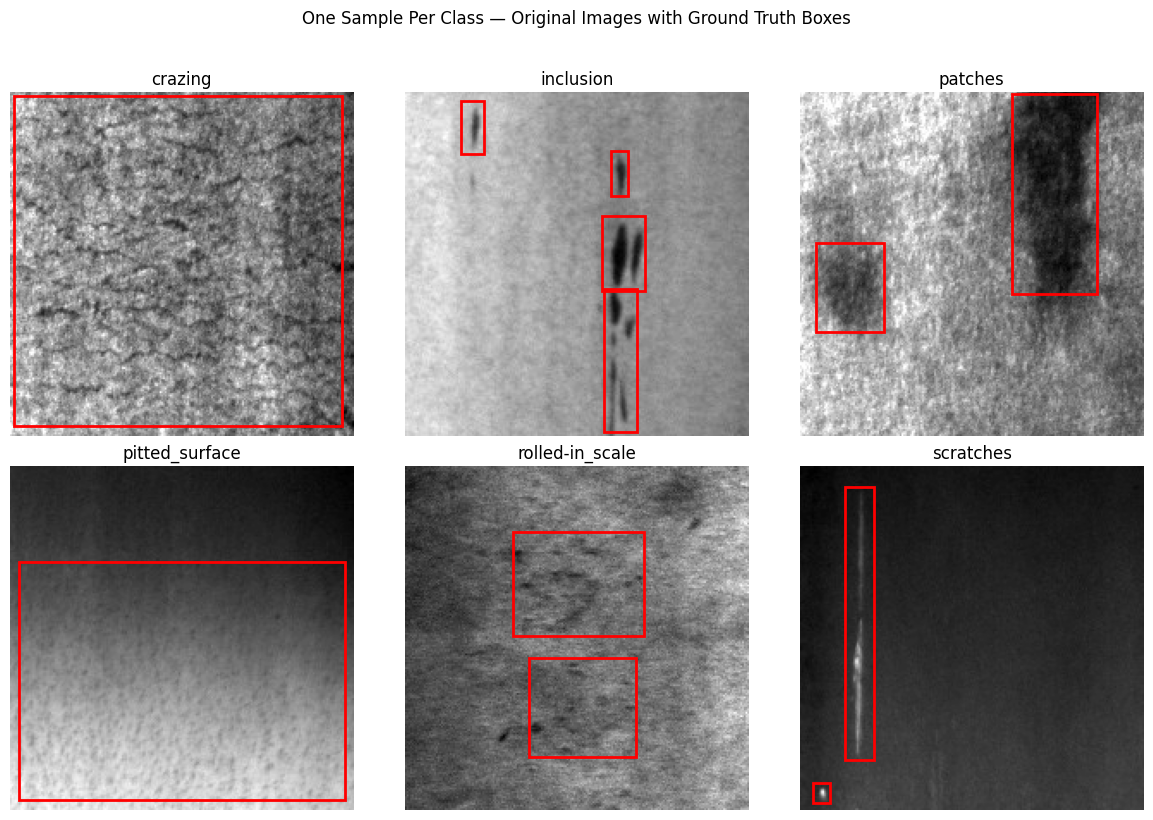

In [6]:
examples = {}
for idx in range(len(train_ds)):
    sample     = train_ds[idx]
    class_name = train_ds.classes[sample["label"]]
    if class_name not in examples:
        examples[class_name] = idx
    if len(examples) == len(train_ds.classes):
        break

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, (class_name, idx) in enumerate(examples.items()):
    sample     = train_ds[idx]
    image_path = sample["image_path"]
    boxes      = train_ds.get_boxes(image_path)
    image      = Image.open(image_path).convert("L")

    axes[i].imshow(image, cmap="gray")

    for box in boxes:
        xmin, ymin, xmax, ymax = box.tolist()
        # scale boxes from 224 space back to original 200 space for display
        scale = 200 / 224
        rect  = patches.Rectangle(
            (xmin * scale, ymin * scale),
            (xmax - xmin) * scale,
            (ymax - ymin) * scale,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )
        axes[i].add_patch(rect)

    axes[i].set_title(class_name)
    axes[i].axis("off")

plt.suptitle("One Sample Per Class — Original Images with Ground Truth Boxes", y=1.02)
plt.tight_layout()
plt.show()

### Image Statistics


Pixel mean — mean: 0.4999  std: 0.1711
Pixel std  — mean: 0.1045  std: 0.0604
Min pixel mean: 0.1347
Max pixel mean: 0.9651


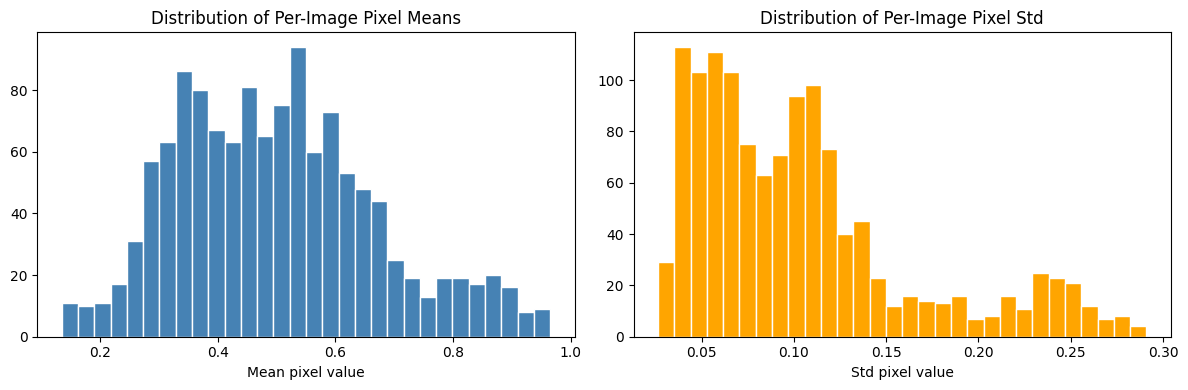

In [7]:
pixel_means = []
pixel_stds  = []

for idx in range(len(train_ds)):
    image_path = str(train_ds.image_paths[idx])
    image      = np.array(Image.open(image_path).convert("L"), dtype=np.float32) / 255.0
    pixel_means.append(image.mean())
    pixel_stds.append(image.std())

pixel_means = np.array(pixel_means)
pixel_stds  = np.array(pixel_stds)

print(f"Pixel mean — mean: {pixel_means.mean():.4f}  std: {pixel_means.std():.4f}")
print(f"Pixel std  — mean: {pixel_stds.mean():.4f}  std: {pixel_stds.std():.4f}")
print(f"Min pixel mean: {pixel_means.min():.4f}")
print(f"Max pixel mean: {pixel_means.max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(pixel_means, bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of Per-Image Pixel Means")
axes[0].set_xlabel("Mean pixel value")
axes[1].hist(pixel_stds,  bins=30, color="orange",   edgecolor="white")
axes[1].set_title("Distribution of Per-Image Pixel Std")
axes[1].set_xlabel("Std pixel value")
plt.tight_layout()
plt.show()

Pixel means are broadly distributed between 0.15 and 0.95, centred 
around 0.3–0.6. This indicates reasonable brightness variety across 
the dataset with no strong bias toward very dark or overexposed images.

Pixel standard deviation is concentrated below 0.15, reflecting the 
low-contrast nature of steel surface images — defects manifest as subtle 
texture changes rather than dramatic brightness differences. This makes 
the classification task genuinely challenging and explains why a strong 
pretrained backbone is more valuable than training from scratch on this 
data.

Both distributions support the use of ImageNet normalisation — the pixel 
statistics are within a reasonable range for pretrained weights to produce 
useful features without significant domain mismatch.

### Bounding Box Size Analysis Per Class


/tmp/ipykernel_6402/3942522279.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


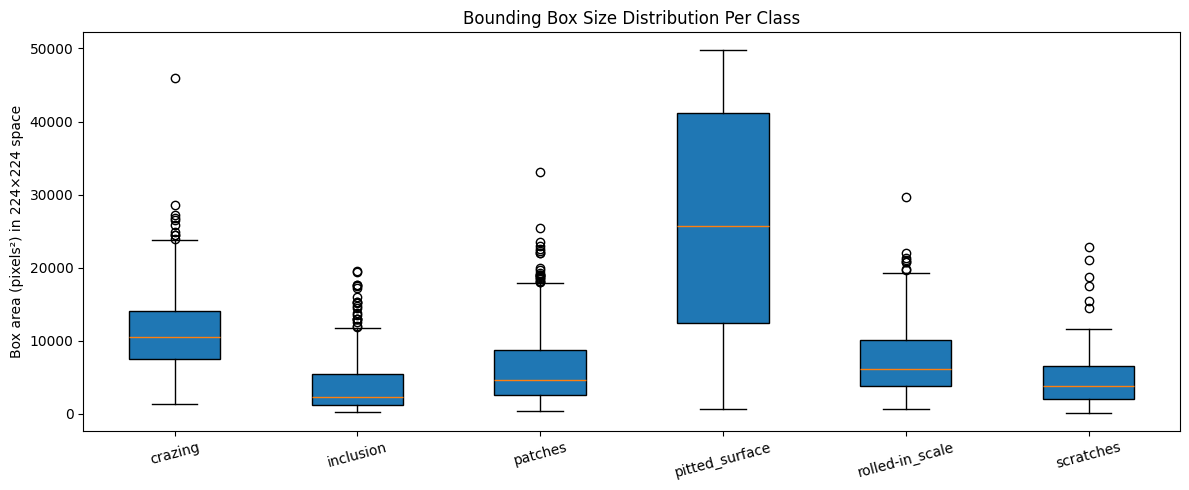


Class                   Mean area  Median area  N boxes
--------------------------------------------------------
crazing                     11316        10500      483
inclusion                    3823         2300      594
patches                      6286         4617      624
pitted_surface              25867        25749      334
rolled-in_scale              7398         6170      436
scratches                    4383         3740      424


In [8]:
box_areas = {c: [] for c in classes}

for idx in range(len(train_ds)):
    sample     = train_ds[idx]
    class_name = train_ds.classes[sample["label"]]
    boxes      = train_ds.get_boxes(str(train_ds.image_paths[idx]))

    for box in boxes:
        xmin, ymin, xmax, ymax = box.tolist()
        area = (xmax - xmin) * (ymax - ymin)
        box_areas[class_name].append(area)

fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot(
    [box_areas[c] for c in classes],
    labels=classes,
    patch_artist=True,
)
ax.set_ylabel("Box area (pixels²) in 224×224 space")
ax.set_title("Bounding Box Size Distribution Per Class")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(f"\n{'Class':<20} {'Mean area':>12} {'Median area':>12} {'N boxes':>8}")
print("-" * 56)
for c in classes:
    areas = box_areas[c]
    print(f"{c:<20} {np.mean(areas):>12.0f} {np.median(areas):>12.0f} {len(areas):>8}")

Pitted surface and crazing show the largest median box areas, covering 
a significant portion of the 224×224 image. This is consistent with the 
diffuse Grad-CAM heatmaps observed for these classes — the defect pattern 
genuinely spans most of the image, so a broad heatmap reflects the 
ground truth rather than a model failure.

Scratches and rolled-in scale show notably smaller, more localised boxes, 
which explains why Grad-CAM produces tighter, more focused heatmaps for 
these classes.

### Boxes Per Image Distribution

Min boxes per image:    1
Max boxes per image:    9
Mean boxes per image:   2.31
Median boxes per image: 2.0


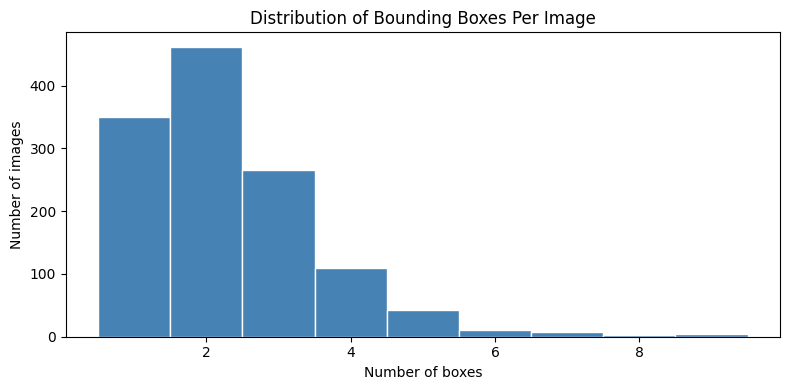

In [9]:
boxes_per_image = []

for idx in range(len(train_ds)):
    boxes = train_ds.get_boxes(str(train_ds.image_paths[idx]))
    boxes_per_image.append(len(boxes))

boxes_per_image = np.array(boxes_per_image)

print(f"Min boxes per image:    {boxes_per_image.min()}")
print(f"Max boxes per image:    {boxes_per_image.max()}")
print(f"Mean boxes per image:   {boxes_per_image.mean():.2f}")
print(f"Median boxes per image: {np.median(boxes_per_image):.1f}")

plt.figure(figsize=(8, 4))
plt.hist(boxes_per_image, bins=range(1, boxes_per_image.max() + 2),
         color="steelblue", edgecolor="white", align="left")
plt.xlabel("Number of boxes")
plt.ylabel("Number of images")
plt.title("Distribution of Bounding Boxes Per Image")
plt.tight_layout()
plt.show()